# A04-2 - Métodos de búsqueda

|                |   |
:----------------|---|
| **Nombre**     |  Emilio Navarro |
| **Fecha**      | 23-03-2026  |
| **Expediente** |  757955 | 

## Importaciones

In [83]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.stats import norm 



## Lista x, y 

In [84]:
X = np.array([10, 2, 3, 7, 12]).reshape(-1, 1)
y = np.array([2847,-4017, -1255, 1773, 563])

## Ajuste inicial del modelo GP



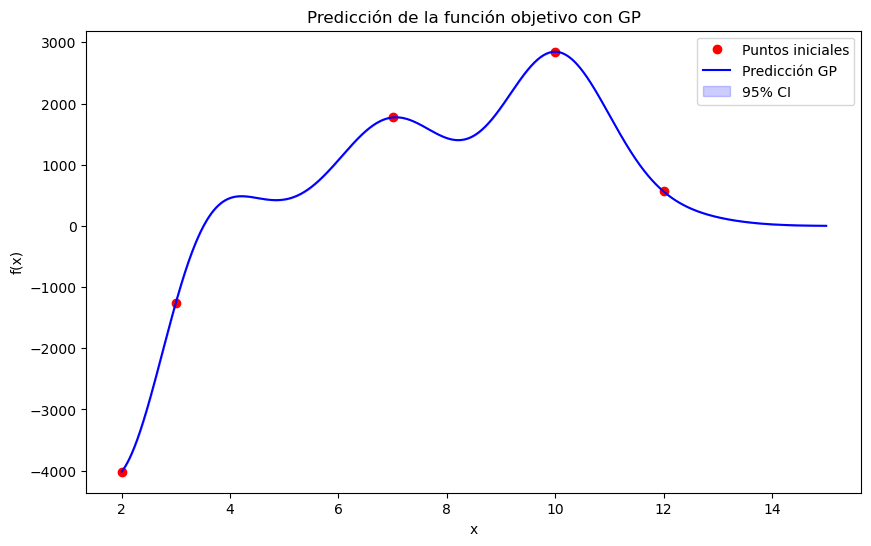

In [85]:
import numpy as np
gp = GaussianProcessRegressor()
gp.fit(X, y)
X_pred = np.linspace(2, 15, 10001).reshape(-1, 1)
y_pred, sigma = gp.predict(X_pred, return_std=True)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(X, y, 'ro', label='Puntos iniciales')
plt.plot(X_pred, y_pred, 'b-', label='Predicción GP')
plt.fill_between(X_pred.ravel(), y_pred - 1.96 * sigma, y_pred + 1.96 * sigma, alpha=0.2, color='blue', label='95% CI')
plt.title('Predicción de la función objetivo con GP')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()


## Simulación de puntos dentro del intervalo de búsqueda



In [86]:
X_sim = np.random.uniform(2, 15, 1000).reshape(-1, 1)
y_sim = objective(X_sim).ravel()


## Primer máximo estimado


In [87]:
max_idx = np.argmax(y_pred)
X_pred[max_idx]

array([9.9963])

## Mejor punto encontrado en la simulación


In [92]:
X_max = X_sim[np.argmax(y_sim)]
y_max = y_sim[np.argmax(y_sim)]

## Actualización de datos con el nuevo punto



In [93]:
X_new = np.array([10, 2, 3, 7, 12, 9.9963]).reshape(-1, 1)
y_new = np.array([2847,-4017, -1255, 1773, 563, 2847.31363])
gp = GaussianProcessRegressor()
gp.fit(X_new, y_new)
X_pred = np.linspace(2, 15, 10001).reshape(-1, 1)
y_pred, sigma_new = gp.predict(X_pred, return_std=True)





## Segundo máximo estimado


In [95]:
max_idx_2 = np.argmax(y_pred)
X_pred[max_idx_2]


array([9.9651])

## Segunda actualización del modelo



In [99]:
X_new_2 = np.array([10, 2, 3, 7, 12, 9.9963, 9.9651]).reshape(-1, 1)
y_new_2 = np.array([2847,-4017, -1255, 1773, 563, 2847.31363, 2849.5981])
gp = GaussianProcessRegressor()
gp.fit(X_new_2, y_new_2)
X_pred_2 = np.linspace(2, 15, 10001).reshape(-1, 1)
y_pred_2, sigma_new_2 = gp.predict(X_pred_2, return_std=True)

## Tercer máximo estimado



In [100]:
max_idx_3 = np.argmax(y_pred_2)
X_pred_2[max_idx_3]

array([9.8741])